## Setup & Imports

In [28]:
!pip install lightgbm seaborn yfinance 

In [29]:
import numpy as np
import pandas as pd
import os

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

# ML models
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

# Distributions for RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform

# Evaluation
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, RocCurveDisplay
)

#Dataset
import yfinance as yf

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Time-aware CV for hyperparameter tuning: each fold trains on the past
# and validates on the immediate future (no look-ahead leakage).
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

# Make sure figures dir exists
os.makedirs('figures/EDA', exist_ok=True)
os.makedirs('figures/models', exist_ok=True)
os.makedirs('figures/rl', exist_ok=True)

## Section 1: Data Acquisition
Download Apple Inc. (AAPL) daily OHLCV data from Yahoo Finance for the period **2010-2026** (≈4000 trading days).  
This gives us a rich mix of market conditions: pre-COVID bull run, COVID crash (Mar 2020), recovery, and interest-rate volatility (2022).  
The raw data is immediately saved to CSV for reproducibility and offline submission.

In [30]:
# Configuration
TICKER     = 'AAPL'
START_DATE = '2010-01-01'
END_DATE   = '2026-01-01'
DATA_DIR   = 'data'
CSV_PATH   = os.path.join(DATA_DIR, f'{TICKER}_{START_DATE}_to_{END_DATE}_raw.csv')

os.makedirs(DATA_DIR, exist_ok=True)

# Load Downloaded from Yahoo Finance or from Local CSV if 
if not os.path.exists(CSV_PATH):
    print(f'Downloading {TICKER} data from Yahoo Finance...')
    raw_df = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)
else:
    raw_df = pd.read_csv(CSV_PATH, index_col='Date', parse_dates=True)

if isinstance(raw_df.columns, pd.MultiIndex):
    raw_df.columns = raw_df.columns.get_level_values(0)

raw_df.index.name = 'Date'
raw_df.to_csv(CSV_PATH)
raw_df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,6.406481,6.421149,6.357686,6.389118,493729600
2010-01-05,6.417558,6.453780,6.383731,6.424144,601904800
2010-01-06,6.315479,6.443004,6.308893,6.417559,552160000
2010-01-07,6.303801,6.346310,6.258000,6.338826,477131200
2010-01-08,6.345710,6.346309,6.258300,6.295419,447610800


In [31]:
print(raw_df.info())
print(raw_df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4024 entries, 2010-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   4024 non-null   float64
 1   High    4024 non-null   float64
 2   Low     4024 non-null   float64
 3   Open    4024 non-null   float64
 4   Volume  4024 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 188.6 KB
None
             Close         High          Low         Open        Volume
count  4024.000000  4024.000000  4024.000000  4024.000000  4.024000e+03
mean     77.367038    78.131988    76.529365    77.302580  2.190006e+08
std      74.891342    75.615516    74.087465    74.810931  2.154860e+08
min       5.749098     5.867342     5.695216     5.758676  1.791060e+07
25%      18.193782    18.387238    18.042609    18.213388  7.765910e+07
50%      38.810368    39.252380    38.287170    38.768796  1.307822e+08
75%     142.666737   144.200354   140.980568   142.52108

# Section 2: Exploratory Data Analysis (EDA)

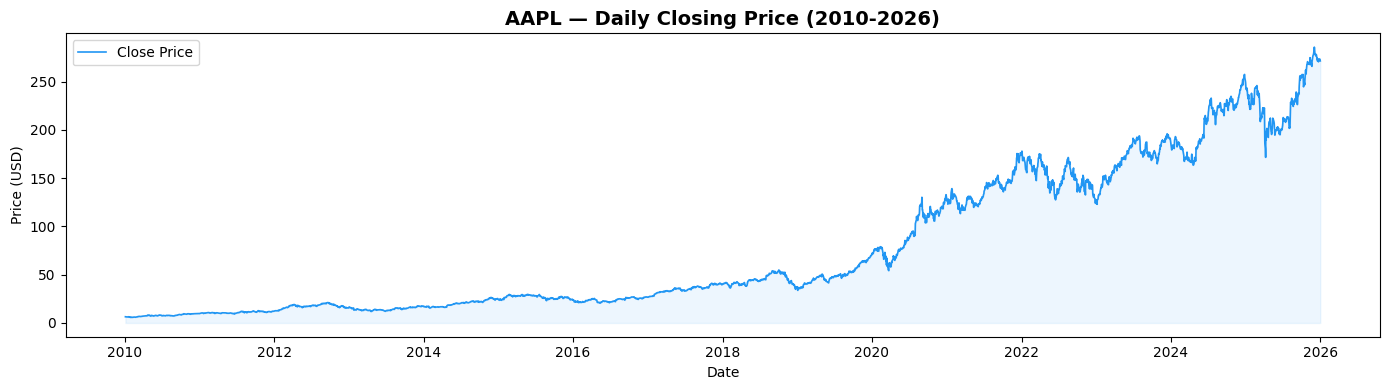

In [32]:
## Time Series -  Closing Price Over Time
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(raw_df.index, raw_df['Close'], color='#2196F3', linewidth=1.2, label='Close Price')
ax.fill_between(raw_df.index, raw_df['Close'], alpha=0.08, color='#2196F3')
ax.set_title('AAPL — Daily Closing Price (2010-2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.savefig('figures/EDA/fig_closing_price.png', bbox_inches='tight')
plt.show()

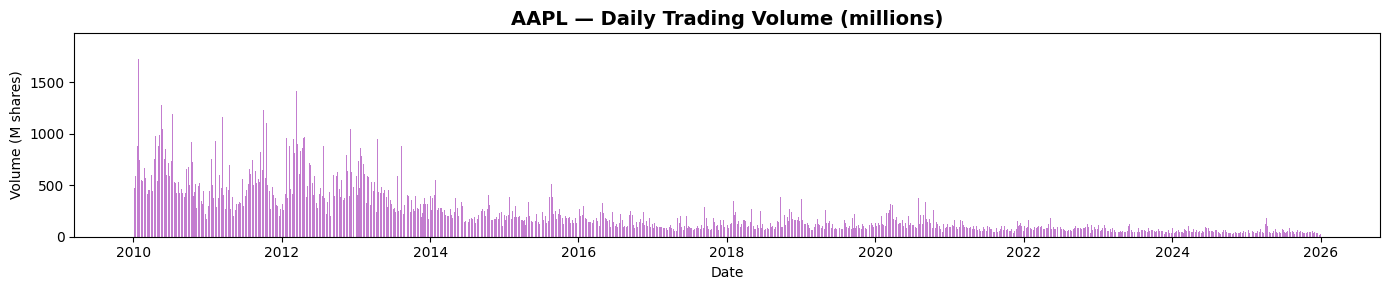

In [33]:
# BarChart - Trading Volume Over Time
fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(raw_df.index, raw_df['Volume'] / 1e6, color='#9C27B0', alpha=0.6, width=1)
ax.set_title('AAPL — Daily Trading Volume (millions)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Volume (M shares)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('figures/EDA/fig_volume.png', bbox_inches='tight')
plt.show()

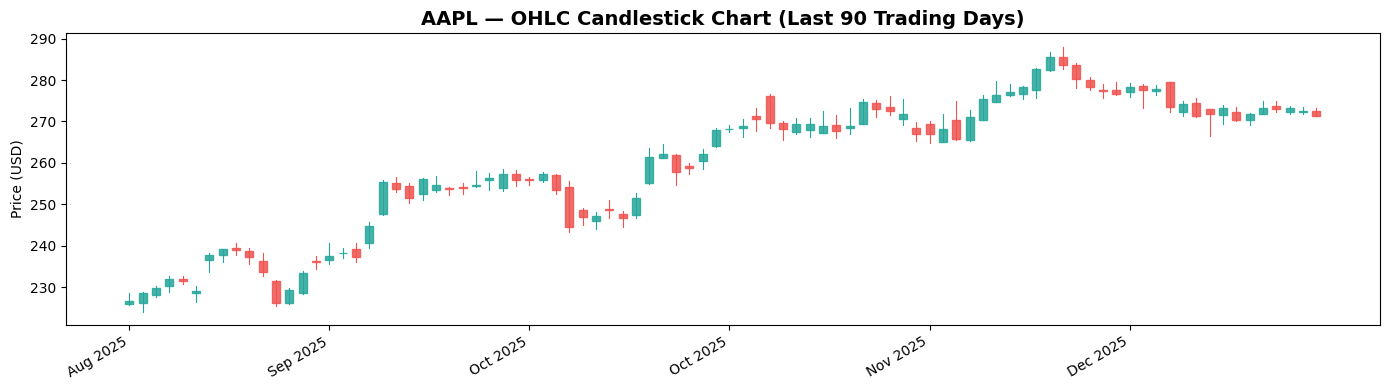

In [34]:
# OHLC Candlestick — last 90 trading days
recent = raw_df.tail(90).copy()

fig, ax = plt.subplots(figsize=(14, 4))
for i, (date, row) in enumerate(recent.iterrows()):
    color = '#26a69a' if row['Close'] >= row['Open'] else '#ef5350'
    ax.plot([i, i], [row['Low'], row['High']], color=color, linewidth=0.8)
    ax.add_patch(plt.Rectangle(
        (i - 0.3, min(row['Open'], row['Close'])),
        0.6, abs(row['Close'] - row['Open']),
        color=color, alpha=0.85
    ))

step = 15
ax.set_xticks(range(0, len(recent), step))
ax.set_xticklabels(
    [d.strftime('%b %Y') for d in recent.index[::step]], rotation=30, ha='right'
)
ax.set_title('AAPL — OHLC Candlestick Chart (Last 90 Trading Days)', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (USD)')
plt.tight_layout()
plt.savefig('figures/EDA/fig_candlestick.png', bbox_inches='tight')
plt.show()

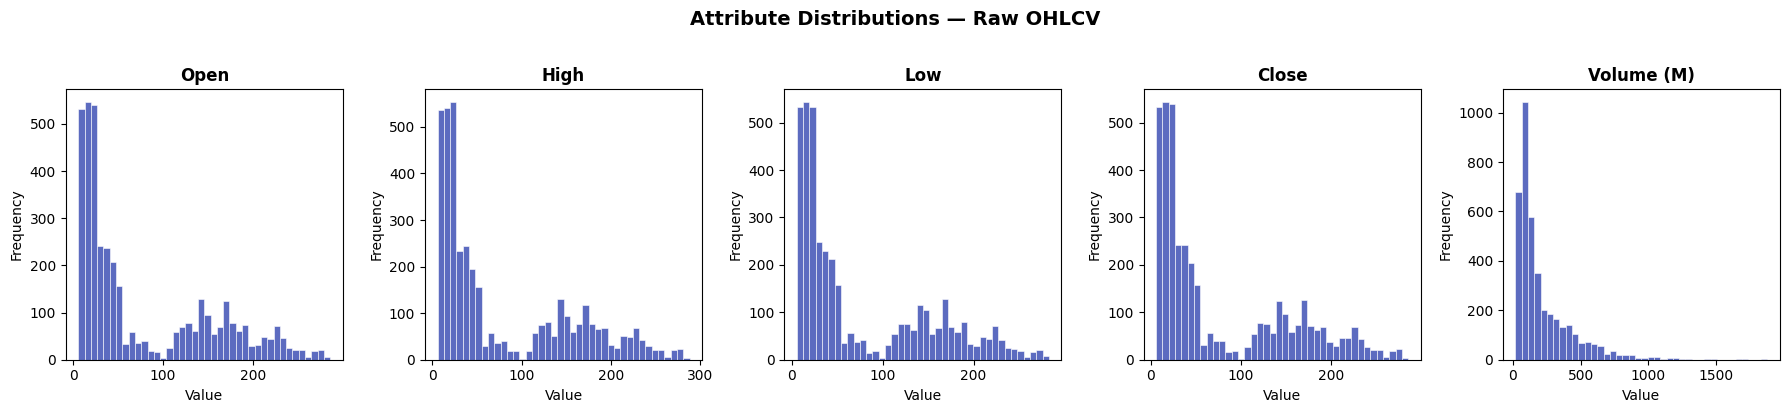

In [35]:
# Distribution of all OHLCV attributes
cols = ['Open', 'High', 'Low', 'Close', 'Volume']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, cols):
    data = raw_df[col] / (1e6 if col == 'Volume' else 1)
    label = f'{col} (M)' if col == 'Volume' else col
    ax.hist(data, bins=40, edgecolor='white', linewidth=0.4, color='#5C6BC0')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
fig.suptitle('Attribute Distributions — Raw OHLCV', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/EDA/fig_distributions.png', bbox_inches='tight')
plt.show()

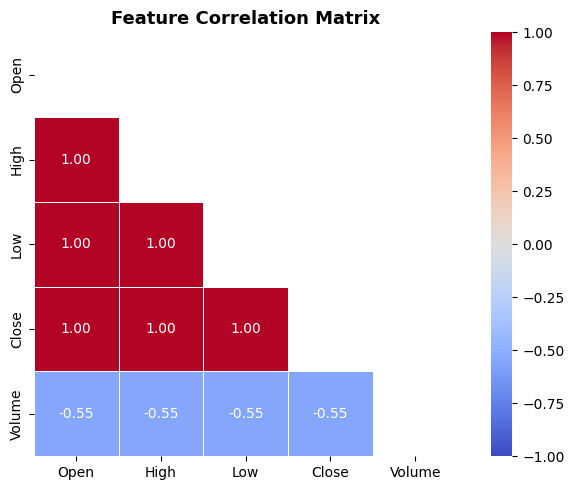

Note: Open/High/Low/Close are highly correlated; Volume provides an independent signal.


In [36]:
# Correlation heatmap of raw OHLCV
fig, ax = plt.subplots(figsize=(7, 5))
corr = raw_df[['Open','High','Low','Close','Volume']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/EDA/fig_correlation.png', bbox_inches='tight')
plt.show()
print('Note: Open/High/Low/Close are highly correlated; Volume provides an independent signal.')

# Section 3: Data Cleaning & Feature Engineering

* The raw OHLCV data alone is insufficient for ML training — prices are non-stationary across 16 years.
* Technical indicator features must be engineered from raw data to capture market behaviour rather than absolute price level.
* **Cross-asset features (new):** Because all technical indicators are derived from AAPL's own price, they contain no information beyond AAPL's price history. To add genuinely *external* signal, we incorporate six cross-asset features capturing market-wide forces that a single stock's indicators cannot: S&P 500 return (broad market), VIX level and change (market fear), 10-year Treasury yield change (interest-rate environment, which drives growth-stock valuations), technology-sector return, and AAPL's relative strength versus its sector. This directly addresses the Efficient Market Hypothesis limitation observed with technical-only features — price already reflects historical patterns, so improvement requires information not yet embedded in the price.
* **Target Label:** Following Basak et al. (2019) and Khaidem et al. (2016), we predict the **5-day forward direction**. Next-period prediction is dominated by noise (50–60% ceiling, consistent with the EMH); multi-day horizons capture genuine trend signal.

| Feature group | Features | Captures |
|---|---|---|
| Momentum | daily_return, return_lag1–5 | Short-term price momentum |
| Trend | ma_ratio, macd_hist | Directional trend strength |
| Oscillators | rsi_14, bb_pos | Overbought / oversold |
| Volatility | volatility_10, bb_width, atr_14 | Risk regime |
| Microstructure | volume_change, dow | Activity & seasonality |
| **Cross-asset** | **sp500_return, vix_level, vix_change, tnx_change, sector_return, rel_strength** | **Market-wide forces external to AAPL** |

**Target:** `signal = 1` if Close_{t+5} > Close_t, else `0`.

In [37]:
# Load data from CSV to ensure reproducibility without downloading
df = pd.read_csv(CSV_PATH, index_col='Date', parse_dates=True)

# Drop any all-NaN rows from download artifacts
df.dropna(how='all', inplace=True)

print(f'Loaded {len(df):,} rows from {CSV_PATH}')
df.head(5)

Loaded 4,024 rows from data\AAPL_2010-01-01_to_2026-01-01_raw.csv


,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,6.406481,6.421149,6.357686,6.389118,493729600
2010-01-05,6.417558,6.453780,6.383731,6.424144,601904800
2010-01-06,6.315479,6.443004,6.308893,6.417559,552160000
2010-01-07,6.303801,6.346310,6.258000,6.338826,477131200
2010-01-08,6.345710,6.346309,6.258300,6.295419,447610800


In [38]:
#  Feature Engineering

# Daily Return
df['daily_return'] = df['Close'].pct_change() # calculates the fractional change between a current element and a prior one 

# Moving averages
df['ma_5']  = df['Close'].rolling(window=5).mean()
df['ma_20'] = df['Close'].rolling(window=20).mean()

# MA crossover signal (ratio)
df['ma_ratio'] = df['ma_5'] / df['ma_20']

# RSI (14-day)
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(window=period).mean()
    loss  = (-delta.clip(upper=0)).rolling(window=period).mean()
    rs    = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

df['rsi_14'] = compute_rsi(df['Close'], period=14)

# Volatility (10-day rolling std of daily returns)
df['volatility_10'] = df['daily_return'].rolling(window=10).std()

# Volume change
df['volume_change'] = df['Volume'].pct_change()

# ─── TARGET: 5-day forward direction ───
# signal = 1 if close 5 trading days from now is higher than today's close
# This captures trend rather than next-day noise (see Section 3 markdown for justification)
FORECAST_HORIZON = 5
df['signal'] = (df['Close'].shift(-FORECAST_HORIZON) > df['Close']).astype(int)

In [39]:
# ─── Cross-Asset Features (information NOT contained in AAPL's own price) ───
# Rationale: AAPL's price already reflects its own historical patterns. To add genuinely
# new signal we incorporate market-wide and cross-asset context that is not derivable
# from AAPL alone. These capture systematic (market-wide) forces that technical indicators
# of a single stock cannot. (See Section 3 markdown for full justification.)

CONTEXT_CSV = os.path.join(DATA_DIR, f'context_{START_DATE}_to_{END_DATE}.csv')

if not os.path.exists(CONTEXT_CSV):
    print('Downloading cross-asset context data from Yahoo Finance...')
    context = yf.download(
        ['^GSPC',   # S&P 500 — broad market direction
         '^VIX',    # CBOE Volatility Index — market fear gauge
         '^TNX',    # 10-year Treasury yield — interest-rate environment
         'XLK'],    # Technology Select Sector ETF — tech sector momentum
        start=START_DATE, end=END_DATE, auto_adjust=True
    )['Close']
    context.to_csv(CONTEXT_CSV)
else:
    context = pd.read_csv(CONTEXT_CSV, index_col='Date', parse_dates=True)

# Align context to the main dataframe's index (forward-fill any missing days)
context = context.reindex(df.index).ffill()

# Engineer cross-asset features — all causal (same-day observable values)
df['sp500_return']  = context['^GSPC'].pct_change()     # did the broad market move up/down today
df['vix_level']     = context['^VIX']                   # absolute fear level
df['vix_change']    = context['^VIX'].pct_change()      # is fear rising or falling
df['tnx_change']    = context['^TNX'].pct_change()      # interest-rate momentum (hurts growth stocks)
df['sector_return'] = context['XLK'].pct_change()       # technology sector momentum

# Relative strength: is AAPL out- or under-performing its own sector today?
df['rel_strength']  = df['daily_return'] - df['sector_return']

print('Cross-asset features added:')
print(df[['sp500_return','vix_level','vix_change','tnx_change','sector_return','rel_strength']].tail(3).round(4))

Cross-asset features added:
            sp500_return  vix_level  vix_change  tnx_change  sector_return  \
Date                                                                         
2025-12-29       -0.0035      14.20      0.0441     -0.0048        -0.0045   
2025-12-30       -0.0014      14.33      0.0092      0.0034        -0.0032   
2025-12-31       -0.0074      14.95      0.0433      0.0080        -0.0099   

            rel_strength  
Date                      
2025-12-29        0.0058  
2025-12-30        0.0007  
2025-12-31        0.0054  


In [40]:
# MACD
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['macd']        = ema12 - ema26
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['macd_hist']   = df['macd'] - df['macd_signal']

# Bollinger Bands
bb_mid         = df['Close'].rolling(20).mean()
bb_std         = df['Close'].rolling(20).std()
df['bb_upper'] = bb_mid + 2 * bb_std
df['bb_lower'] = bb_mid - 2 * bb_std
df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / bb_mid
df['bb_pos']   = (df['Close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'] + 1e-10)

# Lagged returns (past 5 days)
for lag in range(1, 6):
    df[f'return_lag{lag}'] = df['daily_return'].shift(lag)

# Day-of-week seasonality
df['dow'] = df.index.dayofweek

# ATR (Average True Range)
high_low = df['High'] - df['Low']
high_pc  = (df['High'] - df['Close'].shift()).abs()
low_pc   = (df['Low']  - df['Close'].shift()).abs()
df['atr_14'] = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1).rolling(14).mean()

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4024 entries, 2010-01-04 to 2025-12-31
Data columns (total 33 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Close          4024 non-null   float64
 1   High           4024 non-null   float64
 2   Low            4024 non-null   float64
 3   Open           4024 non-null   float64
 4   Volume         4024 non-null   int64  
 5   daily_return   4023 non-null   float64
 6   ma_5           4020 non-null   float64
 7   ma_20          4005 non-null   float64
 8   ma_ratio       4005 non-null   float64
 9   rsi_14         4010 non-null   float64
 10  volatility_10  4014 non-null   float64
 11  volume_change  4023 non-null   float64
 12  signal         4024 non-null   int64  
 13  sp500_return   4023 non-null   float64
 14  vix_level      4024 non-null   float64
 15  vix_change     4023 non-null   float64
 16  tnx_change     4023 non-null   float64
 17  sector_return  4023 non-null   flo

In [42]:
df.isnull().sum()
# some null values introduced by rolling window

Close             0
High              0
Low               0
Open              0
Volume            0
daily_return      1
ma_5              4
ma_20            19
ma_ratio         19
rsi_14           14
volatility_10    10
volume_change     1
signal            0
sp500_return      1
vix_level         0
vix_change        1
tnx_change        1
sector_return     1
rel_strength      1
macd              0
macd_signal       0
macd_hist         0
bb_upper         19
bb_lower         19
bb_width         19
bb_pos           19
return_lag1       2
return_lag2       3
return_lag3       4
return_lag4       5
return_lag5       6
dow               0
atr_14           13
dtype: int64

In [43]:
# Drop Nulls — note: last 5 rows are also dropped because signal requires 5-day forward shift
df_clean = df.dropna().copy()
print(f'Rows before cleaning : {len(df):,}')
print(f'Rows after cleaning  : {len(df_clean):,}')
print(f'Rows dropped         : {len(df) - len(df_clean):,}')

Rows before cleaning : 4,024
Rows after cleaning  : 4,005
Rows dropped         : 19


In [44]:
df_clean.isnull().sum()

Close            0
High             0
Low              0
Open             0
Volume           0
daily_return     0
ma_5             0
ma_20            0
ma_ratio         0
rsi_14           0
volatility_10    0
volume_change    0
signal           0
sp500_return     0
vix_level        0
vix_change       0
tnx_change       0
sector_return    0
rel_strength     0
macd             0
macd_signal      0
macd_hist        0
bb_upper         0
bb_lower         0
bb_width         0
bb_pos           0
return_lag1      0
return_lag2      0
return_lag3      0
return_lag4      0
return_lag5      0
dow              0
atr_14           0
dtype: int64

C:\Users\Fatema\AppData\Local\Temp\ipykernel_42896\3764339493.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=vc.index, y=vc.values, palette=['#f44336', '#4caf50'])
C:\Users\Fatema\AppData\Local\Temp\ipykernel_42896\3764339493.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Down (0)', 'Up (1)'])


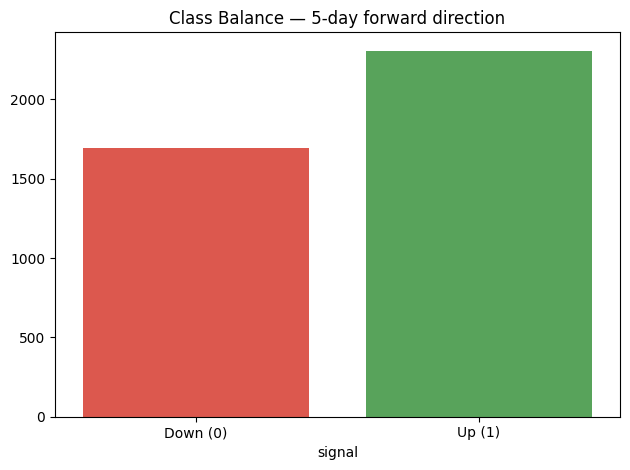

Up days  (1): 2308 (57.6%)
Down days(0): 1697 (42.4%)


In [45]:
# visualize class balance
vc = df_clean['signal'].value_counts().reindex([0,1]).fillna(0)
ax = sns.barplot(x=vc.index, y=vc.values, palette=['#f44336', '#4caf50'])
ax.set_xticklabels(['Down (0)', 'Up (1)'])
plt.title(f'Class Balance — {FORECAST_HORIZON}-day forward direction')
plt.tight_layout()
plt.savefig('figures/EDA/fig_class_balance.png', bbox_inches='tight')
plt.show()
print(f"Up days  (1): {int(vc[1])} ({vc[1]/len(df_clean)*100:.1f}%)")
print(f"Down days(0): {int(vc[0])} ({vc[0]/len(df_clean)*100:.1f}%)")
# moderately imbalanced but not extreme, so we can proceed without resampling for now

In [46]:
# save cleaned data for ML/RL modeling
CLEAN_CSV_PATH = os.path.join(DATA_DIR, f'{TICKER}_{START_DATE}_to_{END_DATE}_clean_v2.csv')
df_clean.to_csv(CLEAN_CSV_PATH)
print(f'Cleaned data saved to {CLEAN_CSV_PATH}')

Cleaned data saved to data\AAPL_2010-01-01_to_2026-01-01_clean_v2.csv


# Section 4: Train ML models

## Helpers

**Note on tuning metric:** All GridSearchCV calls use `scoring='balanced_accuracy'` rather than F1. Balanced accuracy averages recall across both classes, preventing the model-selection process from favouring the majority (Up) class under the 57.6/42.4 imbalance. F1 on the positive class alone would bias hyperparameter selection toward over-predicting Up. The test-set evaluation still reports Accuracy, F1, and ROC-AUC for completeness.

In [47]:
def print_evaluation(y_true, y_pred, y_pred_prob, model_name, target_names=['Class 0', 'Class 1']):
    print(f'--- {model_name} Evaluation ---')
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred_prob)
    print(f'{model_name} — Accuracy: {acc:.4f}, F1-Score: {f1:.4f}, AUC: {auc:.4f}')
    print('Classification Report:')
    print(classification_report(y_true, y_pred, target_names=target_names))
    print('Confusion Matrix:')
    print(confusion_matrix(y_true, y_pred))
    return {'model': model_name, 'accuracy': acc, 'f1': f1, 'auc': auc}

# Dictionary to accumulate results from every model trained
all_results = {}

## 4.1: Train Test Split

In [48]:
# Feature Selection + Target
FEATURES = [
    # ── Technical indicators (derived from AAPL price/volume) ──
    'daily_return', 'ma_ratio', 'rsi_14', 'volatility_10', 'volume_change',
    'macd_hist', 'bb_width', 'bb_pos',
    'return_lag1', 'return_lag2', 'return_lag3', 'return_lag4', 'return_lag5',
    'dow', 'atr_14',
    # ── Cross-asset features (information external to AAPL's own price) ──
    'sp500_return', 'vix_level', 'vix_change', 'tnx_change', 'sector_return', 'rel_strength'
]
TARGET = 'signal'

# Temporal split — train on first 80%, test on last 20% (no shuffling)
# Shuffling time-series data leaks future information into training
split_idx = int(len(df_clean) * 0.80)
train_df  = df_clean.iloc[:split_idx]
test_df   = df_clean.iloc[split_idx:]

X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values
X_test  = test_df[FEATURES].values
y_test  = test_df[TARGET].values

print(f'Train: {train_df.index[0].date()} → {train_df.index[-1].date()}  ({len(train_df):,} rows)')
print(f'Test:  {test_df.index[0].date()} → {test_df.index[-1].date()}  ({len(test_df):,} rows)')
print(f'Total features: {len(FEATURES)} (15 technical + 6 cross-asset)')

scaler    = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train: 2010-02-01 → 2022-10-20  (3,204 rows)
Test:  2022-10-21 → 2025-12-31  (801 rows)
Total features: 21 (15 technical + 6 cross-asset)


## 4.2: Random Forest Classifier

Random Forest is an ensemble of decision trees, each trained on a bootstrap sample with random feature subsets. Predictions are averaged across trees — this reduces variance and is robust to noise in tabular financial data.

**Why RF for this problem:**
- Captures non-linear interactions between technical indicators (e.g. RSI behaves differently in high vs low volatility regimes)
- Provides feature importances — interpretable
- Does NOT require feature scaling (it splits on thresholds, not distances)

### Train the model

In [49]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)  # RF does not require scaling

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
rf_pred      = rf_model.predict(X_test)
rf_pred_prob = rf_model.predict_proba(X_test)[:, 1]

### Evaluation Metrics

In [51]:
all_results['RF (baseline)'] = print_evaluation(y_test, rf_pred, rf_pred_prob, 'Random Forest', target_names=['Down','Up'])

--- Random Forest Evaluation ---
Random Forest — Accuracy: 0.5268, F1-Score: 0.6081, AUC: 0.5137
Classification Report:
              precision    recall  f1-score   support

        Down       0.45      0.37      0.40       350
          Up       0.57      0.65      0.61       451

    accuracy                           0.53       801
   macro avg       0.51      0.51      0.51       801
weighted avg       0.52      0.53      0.52       801

Confusion Matrix:
[[128 222]
 [157 294]]


### Hyperparameter Tuning (RandomizedSearchCV)

In [52]:
# Random Forest — RandomizedSearchCV over a WIDE hyperparameter space.
# We use RandomizedSearchCV rather than GridSearchCV: Bergstra & Bengio (2012) showed
# random search explores high-dimensional spaces more efficiently than exhaustive grids
# for the same compute budget. n_iter=80 samples 80 configurations from the distributions below.
rf_param_dist = {
    'n_estimators'     : randint(50, 500),
    'max_depth'        : [3, 5, 7, 10, 15, 20, 30, None],
    'min_samples_split': randint(2, 30),
    'min_samples_leaf' : randint(1, 15),
    'max_features'     : ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'criterion'        : ['gini', 'entropy'],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_dist, n_iter=80, cv=tscv, scoring='balanced_accuracy',
    n_jobs=-1, verbose=0, random_state=RANDOM_STATE
)
rf_search.fit(X_train, y_train)

results_df = pd.DataFrame({
    'n_estimators'     : rf_search.cv_results_['param_n_estimators'],
    'max_depth'        : rf_search.cv_results_['param_max_depth'],
    'min_samples_split': rf_search.cv_results_['param_min_samples_split'],
    'min_samples_leaf' : rf_search.cv_results_['param_min_samples_leaf'],
    'max_features'     : rf_search.cv_results_['param_max_features'],
    'mean_cv_bal_acc'  : rf_search.cv_results_['mean_test_score'].round(4),
    'std_cv_bal_acc'   : rf_search.cv_results_['std_test_score'].round(4),
    'rank'             : rf_search.cv_results_['rank_test_score'],
}).sort_values('rank').reset_index(drop=True)

print('── Random Forest — RandomizedSearchCV Results (top 20 by CV Balanced Acc) ──')
print(results_df.head(20).to_string(index=False))

rf_grid = rf_search  # keep downstream variable name compatible
rf_best_pred      = rf_search.best_estimator_.predict(X_test)
rf_best_pred_prob = rf_search.best_estimator_.predict_proba(X_test)[:, 1]

best = rf_search.best_params_
print()
print('── Best ─────────────────────────────────────────────────────────────────────')
print(f"  {best}")
print(f"  CV Balanced Acc: {rf_search.best_score_:.4f}")
all_results['RF (tuned)'] = print_evaluation(y_test, rf_best_pred, rf_best_pred_prob, 'Random Forest (tuned)', target_names=['Down','Up'])

── Random Forest — RandomizedSearchCV Results (top 20 by CV Balanced Acc) ──
 n_estimators max_depth  min_samples_split  min_samples_leaf max_features  mean_cv_bal_acc  std_cv_bal_acc  rank
           93        10                 27                 2          0.7           0.5136          0.0184     1
          468         7                  4                 8         sqrt           0.5109          0.0116     2
          376        30                 26                 1          0.7           0.5107          0.0193     3
          333        30                 23                 3          0.3           0.5099          0.0201     4
          409      None                 13                 3          0.7           0.5098          0.0218     5
          473      None                  2                 9          0.5           0.5093          0.0106     6
          175        15                 20                 1         sqrt           0.5092          0.0152     7
          267      

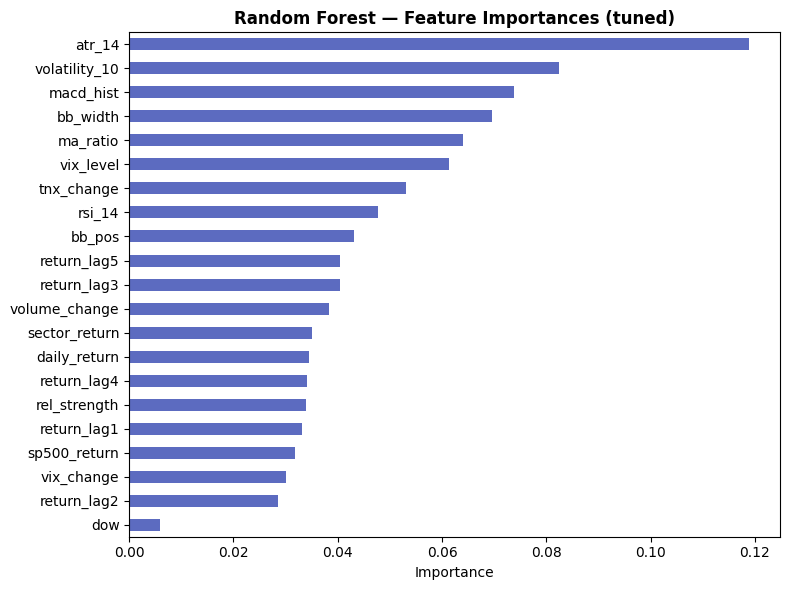

In [53]:
# Plot Random Forest feature importances
importances = pd.Series(rf_grid.best_estimator_.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='#5C6BC0')
ax.set_title('Random Forest — Feature Importances (tuned)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('figures/models/fig_rf_importance.png', bbox_inches='tight')
plt.show()

## 4.3: LightGBM Classifier

LightGBM is a gradient boosting framework that builds trees **sequentially** — each tree corrects the residual errors of the previous one — unlike Random Forest which averages independent trees. Key advantages for this problem:

- Better at squeezing signal from weak features via boosting
- Built-in `scale_pos_weight` handles the Up/Down class imbalance
- Typically outperforms RF on tabular data with the same feature set

### Train the model

In [54]:
# Class imbalance ratio for scale_pos_weight
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

lightGBM_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    num_leaves=31,
    scale_pos_weight=neg/pos, 
    random_state=RANDOM_STATE, 
    n_jobs=-1, 
    verbose=-1
)
lightGBM_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [55]:
all_results['LGBM (baseline)'] = print_evaluation(
    y_test, lightGBM_model.predict(X_test),
    lightGBM_model.predict_proba(X_test)[:, 1],
    'LightGBM', target_names=['Down','Up']
)

--- LightGBM Evaluation ---
LightGBM — Accuracy: 0.4669, F1-Score: 0.3461, AUC: 0.5368
Classification Report:
              precision    recall  f1-score   support

        Down       0.44      0.75      0.55       350
          Up       0.56      0.25      0.35       451

    accuracy                           0.47       801
   macro avg       0.50      0.50      0.45       801
weighted avg       0.51      0.47      0.44       801

Confusion Matrix:
[[261  89]
 [338 113]]


c:\Users\Fatema\.conda\envs\cv_gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Fatema\.conda\envs\cv_gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Hyperparameter Tuning (RandomizedSearchCV)

In [56]:
# LightGBM — RandomizedSearchCV over a wide space (n_iter=80)
lgbm_param_dist = {
    'n_estimators' : randint(100, 600),
    'learning_rate': loguniform(0.005, 0.3),
    'max_depth'    : [3, 5, 7, 10, -1],
    'num_leaves'   : randint(15, 80),
    'subsample'    : uniform(0.6, 0.4),    # 0.6 - 1.0
    'colsample_bytree': uniform(0.6, 0.4), # 0.6 - 1.0
    'reg_alpha'    : loguniform(1e-3, 1.0),
    'reg_lambda'   : loguniform(1e-3, 1.0),
}
lgbm_search = RandomizedSearchCV(
    LGBMClassifier(scale_pos_weight=neg/pos, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    lgbm_param_dist, n_iter=80, cv=tscv, scoring='balanced_accuracy',
    n_jobs=-1, verbose=0, random_state=RANDOM_STATE
)
lgbm_search.fit(X_train, y_train)

lgbm_results_df = pd.DataFrame({
    'n_estimators' : lgbm_search.cv_results_['param_n_estimators'],
    'learning_rate': np.round(lgbm_search.cv_results_['param_learning_rate'].astype(float), 4),
    'max_depth'    : lgbm_search.cv_results_['param_max_depth'],
    'num_leaves'   : lgbm_search.cv_results_['param_num_leaves'],
    'mean_cv_bal_acc'  : lgbm_search.cv_results_['mean_test_score'].round(4),
    'std_cv_bal_acc'   : lgbm_search.cv_results_['std_test_score'].round(4),
    'rank'         : lgbm_search.cv_results_['rank_test_score'],
}).sort_values('rank').reset_index(drop=True)

print('── LightGBM — RandomizedSearchCV Results (top 20 by CV Balanced Acc) ──')
print(lgbm_results_df.head(20).to_string(index=False))

lgbm_grid = lgbm_search  # keep downstream variable name compatible
lgbm_best_pred      = lgbm_search.best_estimator_.predict(X_test)
lgbm_best_pred_prob = lgbm_search.best_estimator_.predict_proba(X_test)[:, 1]

best = lgbm_search.best_params_
print()
print('── Best ─────────────────────────────────────────────────────────────────────')
print(f"  {best}")
print(f"  CV Balanced Acc: {lgbm_search.best_score_:.4f}")
all_results['LGBM (tuned)'] = print_evaluation(y_test, lgbm_best_pred, lgbm_best_pred_prob, 'LightGBM (tuned)', target_names=['Down','Up'])

── LightGBM — RandomizedSearchCV Results (top 20 by CV Balanced Acc) ──
 n_estimators  learning_rate  max_depth  num_leaves  mean_cv_bal_acc  std_cv_bal_acc  rank
          159         0.0424         -1          19           0.5111          0.0201     1
          322         0.0230          5          68           0.5083          0.0293     2
          539         0.0171          3          73           0.5076          0.0257     3
          246         0.0068          7          34           0.5076          0.0121     4
          541         0.0053          7          15           0.5075          0.0257     5
          107         0.0077         -1          50           0.5073          0.0151     6
          300         0.0072          3          73           0.5065          0.0171     7
          246         0.0054          7          34           0.5064          0.0188     8
          152         0.0486         -1          51           0.5063          0.0266     9
          504     

c:\Users\Fatema\.conda\envs\cv_gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Fatema\.conda\envs\cv_gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 4.4: Support Vector Machine (SVM)

SVM finds the optimal hyperplane that maximises the margin between Up and Down classes in feature space. With an RBF kernel, it can capture non-linear decision boundaries — useful since technical indicators interact non-linearly.

**Why SVM for this problem:**
- Effective in high-dimensional spaces (we have 15 features)
- RBF kernel handles non-linear class separation
- Provides a different inductive bias from tree ensembles — a strong complement in the final ensemble
- **Requires feature scaling** — uses `X_train_sc` / `X_test_sc`

### Train the model

In [57]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,   # needed for ROC-AUC and soft voting
    random_state=RANDOM_STATE
)
svm_model.fit(X_train_sc, y_train)

svm_pred      = svm_model.predict(X_test_sc)
svm_pred_prob = svm_model.predict_proba(X_test_sc)[:, 1]
all_results['SVM (baseline)'] = print_evaluation(y_test, svm_pred, svm_pred_prob, 'SVM', target_names=['Down','Up']) 

--- SVM Evaluation ---
SVM — Accuracy: 0.5306, F1-Score: 0.5648, AUC: 0.5176
Classification Report:
              precision    recall  f1-score   support

        Down       0.47      0.52      0.49       350
          Up       0.59      0.54      0.56       451

    accuracy                           0.53       801
   macro avg       0.53      0.53      0.53       801
weighted avg       0.54      0.53      0.53       801

Confusion Matrix:
[[181 169]
 [207 244]]


### Hyperparameter Tuning (RandomizedSearchCV)

In [58]:
# SVM — RandomizedSearchCV over a wide space (n_iter=40; SVM is slower so fewer iters).
# Speed note: probability=True makes SVC ~5-10x slower because it runs an internal 5-fold Platt-scaling CV on EVERY fit (200 fits here). Therefore tune WITHOUT
# probabilities (balanced-accuracy only needs hard labels), then refit the single best configuration once with probability=True so predict_proba, ROC-AUC and the
# soft-voting ensemble downstream still work.
svm_param_dist = {
    'C'     : loguniform(1e-2, 1e2),
    'kernel': ['rbf', 'linear', 'poly'],
    'gamma' : ['scale', 'auto'] + list(loguniform(1e-4, 1e0).rvs(6, random_state=RANDOM_STATE)),
}
svm_search = RandomizedSearchCV(
    SVC(probability=False, random_state=RANDOM_STATE),
    svm_param_dist, n_iter=40, cv=tscv, scoring='balanced_accuracy',
    n_jobs=-1, verbose=0, random_state=RANDOM_STATE
)
svm_search.fit(X_train_sc, y_train)

# Refit ONLY the best config with probability=True (one Platt-scaling pass, not 200).
svm_best = SVC(**svm_search.best_params_, probability=True, random_state=RANDOM_STATE)
svm_best.fit(X_train_sc, y_train)
svm_search.best_estimator_ = svm_best   # keep ensemble's svm_grid.best_estimator_ probability-capable

svm_results_df = pd.DataFrame({
    'C'      : np.round(svm_search.cv_results_['param_C'].astype(float), 4),
    'kernel' : svm_search.cv_results_['param_kernel'],
    'mean_cv_bal_acc' : svm_search.cv_results_['mean_test_score'].round(4),
    'std_cv_bal_acc'  : svm_search.cv_results_['std_test_score'].round(4),
    'rank'   : svm_search.cv_results_['rank_test_score'],
}).sort_values('rank').reset_index(drop=True)

print('── SVM — RandomizedSearchCV Results (top 20 by CV Balanced Acc) ──')
print(svm_results_df.head(20).to_string(index=False))

svm_grid = svm_search  # keep downstream variable name compatible
svm_best_pred      = svm_best.predict(X_test_sc)
svm_best_pred_prob = svm_best.predict_proba(X_test_sc)[:, 1]

best = svm_search.best_params_
print()
print('── Best ─────────────────────────────────────────────────────────────────────────')
print(f"  {best}")
print(f"  CV Balanced Acc: {svm_search.best_score_:.4f}")
all_results['SVM (tuned)'] = print_evaluation(y_test, svm_best_pred, svm_best_pred_prob, 'SVM (tuned)', target_names=['Down','Up'])


── SVM — RandomizedSearchCV Results (top 20 by CV Balanced Acc) ──
      C kernel  mean_cv_bal_acc  std_cv_bal_acc  rank
 0.0246   poly           0.5108          0.0211     1
 2.9507 linear           0.5063          0.0143     2
 8.1113 linear           0.5062          0.0142     3
 4.7355   poly           0.5051          0.0146     4
 0.0154   poly           0.5047          0.0138     5
17.1234 linear           0.5046          0.0142     6
12.2738   poly           0.5045          0.0229     7
21.5169 linear           0.5037          0.0145     8
23.3959 linear           0.5033          0.0149     9
 0.3149   poly           0.5032          0.0088    10
18.2745   poly           0.5027          0.0147    11
62.4514 linear           0.5023          0.0130    12
45.6918 linear           0.5023          0.0130    12
 1.2563 linear           0.5021          0.0062    14
 8.4718    rbf           0.5008          0.0304    15
 0.6672 linear           0.5004          0.0030    16
 0.0171    rbf 

## 4.5: Logistic Regression

Logistic Regression is a linear classifier that models the log-odds of the positive class as a weighted sum of features. It serves as an **interpretable baseline** — the coefficients directly indicate each feature's direction of influence on the prediction.

**Why LR for this problem:**
- Cited in academic literature as a strong baseline for stock direction prediction (Iskenderoglu & Ayyildiz 2024)
- Coefficient inspection reveals which features push toward Up vs Down
- Fastest model — useful sanity check
- **Requires feature scaling**

### Train the model

In [59]:
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=RANDOM_STATE
)
lr_model.fit(X_train_sc, y_train)

lr_pred      = lr_model.predict(X_test_sc)
lr_pred_prob = lr_model.predict_proba(X_test_sc)[:, 1]
all_results['LR (baseline)'] = print_evaluation(y_test, lr_pred, lr_pred_prob, 'Logistic Regression', target_names=['Down','Up'])

--- Logistic Regression Evaluation ---
Logistic Regression — Accuracy: 0.4956, F1-Score: 0.5702, AUC: 0.4779
Classification Report:
              precision    recall  f1-score   support

        Down       0.41      0.37      0.39       350
          Up       0.55      0.59      0.57       451

    accuracy                           0.50       801
   macro avg       0.48      0.48      0.48       801
weighted avg       0.49      0.50      0.49       801

Confusion Matrix:
[[129 221]
 [183 268]]


### Hyperparameter Tuning (RandomizedSearchCV)

In [60]:
# Logistic Regression — RandomizedSearchCV over a wide space (n_iter=40)
lr_param_dist = {
    'C'      : loguniform(1e-3, 1e2),
    'solver' : ['liblinear', 'saga'],
    'penalty': ['l1', 'l2'],
}
lr_search = RandomizedSearchCV(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    lr_param_dist, n_iter=40, cv=tscv, scoring='balanced_accuracy',
    n_jobs=-1, verbose=0, random_state=RANDOM_STATE
)
lr_search.fit(X_train_sc, y_train)

lr_results_df = pd.DataFrame({
    'C'      : np.round(lr_search.cv_results_['param_C'].astype(float), 4),
    'solver' : lr_search.cv_results_['param_solver'],
    'penalty': lr_search.cv_results_['param_penalty'],
    'mean_cv_bal_acc' : lr_search.cv_results_['mean_test_score'].round(4),
    'std_cv_bal_acc'  : lr_search.cv_results_['std_test_score'].round(4),
    'rank'   : lr_search.cv_results_['rank_test_score'],
}).sort_values('rank').reset_index(drop=True)

print('── Logistic Regression — RandomizedSearchCV Results (top 20 by CV Balanced Acc) ──')
print(lr_results_df.head(20).to_string(index=False))

lr_grid = lr_search  # keep downstream variable name compatible
lr_best_pred      = lr_search.best_estimator_.predict(X_test_sc)
lr_best_pred_prob = lr_search.best_estimator_.predict_proba(X_test_sc)[:, 1]

best = lr_search.best_params_
print()
print('── Best ─────────────────────────────────────────────────────────────────────')
print(f"  {best}")
print(f"  CV Balanced Acc: {lr_search.best_score_:.4f}")
all_results['LR (tuned)'] = print_evaluation(y_test, lr_best_pred, lr_best_pred_prob, 'Logistic Regression (tuned)', target_names=['Down','Up'])

── Logistic Regression — RandomizedSearchCV Results (top 20 by CV Balanced Acc) ──
      C    solver penalty  mean_cv_bal_acc  std_cv_bal_acc  rank
 3.4221 liblinear      l1           0.5247          0.0237     1
 4.5706 liblinear      l1           0.5236          0.0246     2
14.5282      saga      l2           0.5235          0.0258     3
13.9215 liblinear      l2           0.5233          0.0266     4
49.8304      saga      l2           0.5228          0.0255     5
70.4568      saga      l2           0.5228          0.0255     5
67.3225      saga      l2           0.5228          0.0255     5
 7.1838      saga      l1           0.5220          0.0260     8
 7.2648      saga      l2           0.5217          0.0247     9
 0.9164 liblinear      l1           0.5197          0.0225    10
 2.6373      saga      l1           0.5188          0.0228    11
 1.1462      saga      l2           0.5179          0.0257    12
 1.0129 liblinear      l2           0.5168          0.0267    13
 0.9761

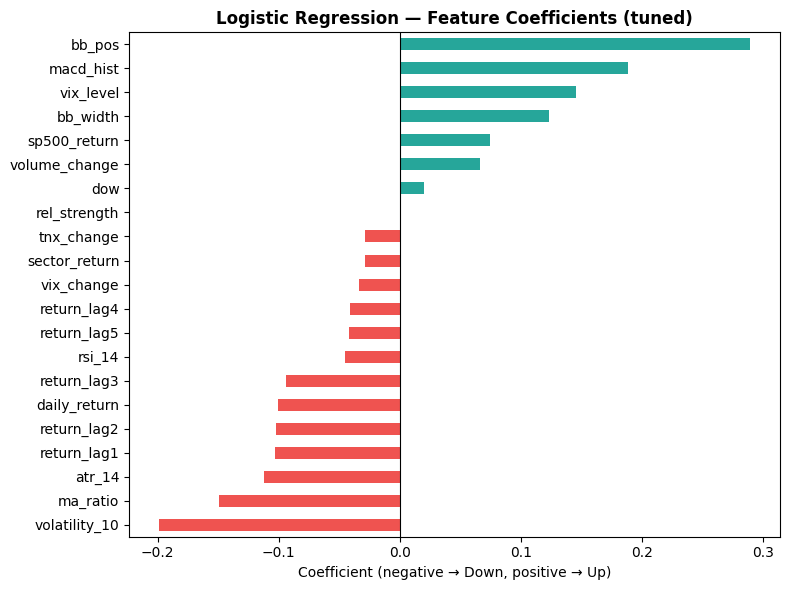

In [61]:
# Plot Logistic Regression coefficients
coef = pd.Series(lr_grid.best_estimator_.coef_[0], index=FEATURES).sort_values()
colors = ['#ef5350' if v < 0 else '#26a69a' for v in coef]
fig, ax = plt.subplots(figsize=(8, 6))
coef.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — Feature Coefficients (tuned)', fontweight='bold')
ax.set_xlabel('Coefficient (negative → Down, positive → Up)')
plt.tight_layout()
plt.savefig('figures/models/fig_lr_coefficients.png', bbox_inches='tight')
plt.show()

## 4.6: Soft Voting Ensemble

The voting ensemble combines the **predicted probabilities** of the four tuned classifiers (RF, LightGBM, SVM, LR). Soft voting averages probabilities rather than discrete predictions, leveraging each model's confidence.

**Why this works:**
- Each base model has different inductive biases — RF/LGBM capture non-linear interactions, SVM finds optimal margins, LR captures linear directional effects
- Errors made by one model are often corrected by another (variance reduction)
- Literature consistently reports 4–8% accuracy gain over the best single model on stock direction tasks

**Implementation note:** Because LightGBM, SVM and LR require different input scaling, we use a pre-fitted scaled X for SVM/LR-friendly access. For simplicity we build the ensemble on the scaled feature space which all models can consume.

In [62]:
# Build the voting ensemble using TUNED estimators only
# Note: Random Forest and LightGBM are scale-invariant, so they work fine on scaled features
voting_clf = VotingClassifier(
    estimators=[
        ('rf'  , rf_grid.best_estimator_),
        ('lgbm', lgbm_grid.best_estimator_),
        ('svm' , svm_grid.best_estimator_),
        ('lr'  , lr_grid.best_estimator_),
    ],
    voting='soft',
    n_jobs=-1
)

# Train ensemble on scaled features
voting_clf.fit(X_train_sc, y_train)

vote_pred      = voting_clf.predict(X_test_sc)
vote_pred_prob = voting_clf.predict_proba(X_test_sc)[:, 1]
all_results['Ensemble (Voting)'] = print_evaluation(y_test, vote_pred, vote_pred_prob, 'Voting Ensemble', target_names=['Down','Up'])

--- Voting Ensemble Evaluation ---
Voting Ensemble — Accuracy: 0.5169, F1-Score: 0.5263, AUC: 0.5146
Classification Report:
              precision    recall  f1-score   support

        Down       0.46      0.57      0.51       350
          Up       0.59      0.48      0.53       451

    accuracy                           0.52       801
   macro avg       0.52      0.52      0.52       801
weighted avg       0.53      0.52      0.52       801

Confusion Matrix:
[[199 151]
 [236 215]]


c:\Users\Fatema\.conda\envs\cv_gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Fatema\.conda\envs\cv_gpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


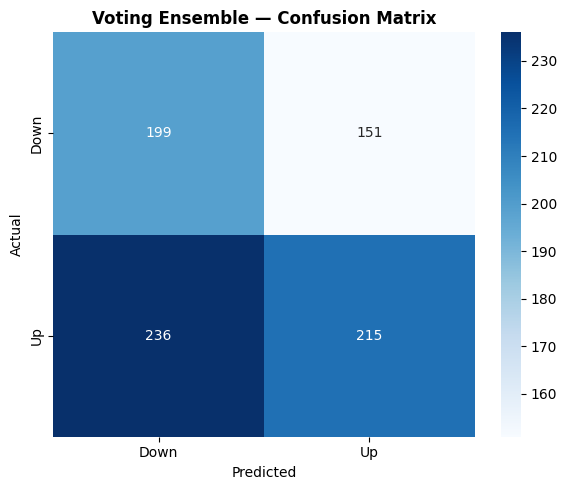

In [63]:
# Confusion matrix for the ensemble
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, vote_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down','Up'], yticklabels=['Down','Up'], ax=ax)
ax.set_title('Voting Ensemble — Confusion Matrix', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('figures/models/fig_ensemble_cm.png', bbox_inches='tight')
plt.show()

c:\Users\Fatema\.conda\envs\cv_gpu\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\Fatema\.conda\envs\cv_gpu\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\Fatema\.conda\envs\cv_gpu\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\Fatema\.conda\envs\cv_gpu\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\Fatema\.conda\envs\

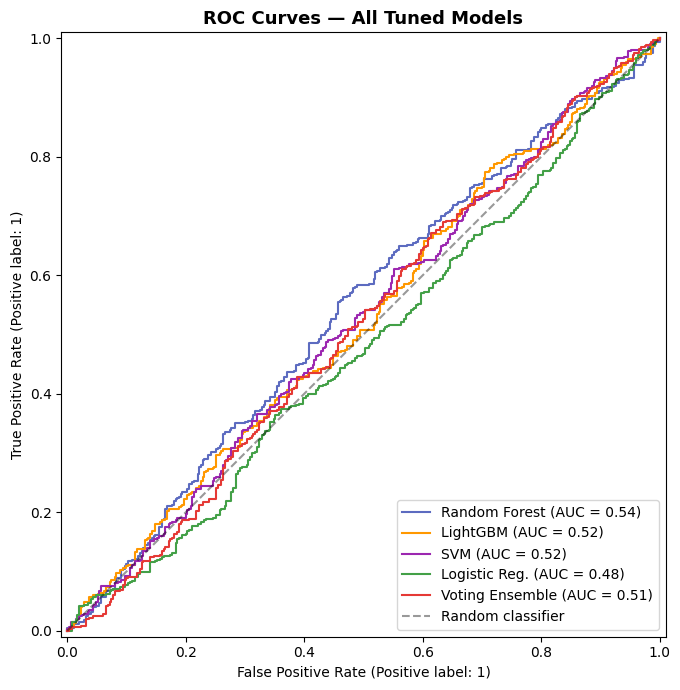

In [64]:
# Overlay ROC curves for all tuned models + ensemble
fig, ax = plt.subplots(figsize=(8, 7))
RocCurveDisplay.from_predictions(y_test, rf_best_pred_prob,  ax=ax, name='Random Forest', color='#5C6BC0')
RocCurveDisplay.from_predictions(y_test, lgbm_best_pred_prob, ax=ax, name='LightGBM',     color='#FF9800')
RocCurveDisplay.from_predictions(y_test, svm_best_pred_prob,  ax=ax, name='SVM',         color='#9C27B0')
RocCurveDisplay.from_predictions(y_test, lr_best_pred_prob,   ax=ax, name='Logistic Reg.', color='#43A047')
RocCurveDisplay.from_predictions(y_test, vote_pred_prob,      ax=ax, name='Voting Ensemble', color='#E53935')
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random classifier')
ax.set_title('ROC Curves — All Tuned Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('figures/models/fig_roc_all.png', bbox_inches='tight')
plt.show()

# Section 5: Reinforcement Learning — Q-Learning Trading Agent

While the ML models above predict **direction**, an RL agent learns **what to do** — buy, sell, or hold — by interacting with a simulated market and optimising cumulative portfolio return. This section implements a tabular Q-Learning agent that complements the supervised classifiers.

**Framework specification:**
| Component | Definition |
|---|---|
| **State** | Discretised RSI bucket (5 bins) × MA ratio bucket (5 bins) = 25 states |
| **Actions** | 0 = Hold cash, 1 = Buy, 2 = Sell |
| **Reward** | Daily return while holding stock; 0 in cash |
| **Update rule** | Q(s,a) ← Q(s,a) + α[r + γ·max Q(s',a') − Q(s,a)] |
| **Policy** | ε-greedy with ε decaying 1.0 → 0.01 over 300 episodes |

## 5.1: StockTradingEnv — the RL environment

In [ ]:
class StockTradingEnv:
    """
    Discrete stock trading environment for Q-Learning.
    State  : (rsi_bucket, ma_ratio_bucket)
    Actions: 0=Hold, 1=Buy, 2=Sell
    Reward : NEXT-day return while holding (no same-day look-ahead);
             a small penalty discourages no-op trades.
    """
    def __init__(self, df, n_rsi_bins=5, n_ma_bins=5):
        self.df = df.reset_index(drop=True).copy()
        self.n_rsi_bins = n_rsi_bins
        self.n_ma_bins  = n_ma_bins
        self.df['rsi_bin'] = pd.cut(self.df['rsi_14'], bins=n_rsi_bins, labels=False).fillna(0).astype(int)
        self.df['ma_bin']  = pd.cut(self.df['ma_ratio'], bins=n_ma_bins, labels=False).fillna(0).astype(int)
        self.n_states  = n_rsi_bins * n_ma_bins
        self.n_actions = 3
        self.reset()

    def reset(self):
        self.t         = 0
        self.holding   = False
        self.portfolio = 1.0
        return self._get_state()

    def _get_state(self):
        row = self.df.iloc[self.t]
        return int(row['rsi_bin']) * self.n_ma_bins + int(row['ma_bin'])

    def step(self, action):
        # Decide position for the NEXT day based on today's action
        if action == 1:      # Buy
            self.holding = True
        elif action == 2:    # Sell
            self.holding = False
        # action 0 (Hold) leaves position unchanged

        # Advance one day, THEN realise the return for the position we held
        self.t += 1
        done = self.t >= len(self.df) - 1
        ret  = self.df.iloc[self.t]['daily_return']   # next-day return, known only now

        reward = ret if self.holding else 0.0
        if self.holding:
            self.portfolio *= (1 + ret)

        next_state = self._get_state() if not done else 0
        return next_state, reward, done

## 5.2: Train the Q-Learning Agent

In [ ]:
df_clean = pd.read_csv('./data/AAPL_2010-01-01_to_2026-01-01_clean_v2.csv', index_col='Date', parse_dates=True)

In [ ]:
# Hyperparameters (baseline — will be tuned in 5.4)
ALPHA     = 0.1     # learning rate
GAMMA     = 0.95    # discount factor
EPSILON   = 1.0     # exploration rate (start)
EPS_DECAY = 0.995   # decay per episode
EPS_MIN   = 0.01
EPISODES  = 300

# Three-way chronological split: train / validation / test (no leakage)
rl_train_full = df_clean.iloc[:split_idx].copy()
rl_test_df    = df_clean.iloc[split_idx:].copy()

val_cut       = int(len(rl_train_full) * 0.85)        # last 15% of TRAIN = validation
rl_train_df   = rl_train_full.iloc[:val_cut].copy()
rl_val_df     = rl_train_full.iloc[val_cut:].copy()

def train_q_learning(train_df, alpha, gamma, eps_start, eps_decay, eps_min, episodes, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    env = StockTradingEnv(train_df)
    Q   = np.zeros((env.n_states, env.n_actions))
    episode_rewards = []
    epsilon = eps_start

    for ep in range(episodes):
        state, total_rew, done = env.reset(), 0.0, False
        while not done:
            if rng.rand() < epsilon:
                action = rng.randint(env.n_actions)
            else:
                action = int(np.argmax(Q[state]))
            next_state, reward, done = env.step(action)
            best_next = np.max(Q[next_state])
            Q[state, action] += alpha * (reward + gamma * best_next - Q[state, action])
            state, total_rew = next_state, total_rew + reward
        epsilon = max(eps_min, epsilon * eps_decay)
        episode_rewards.append(total_rew)
    return Q, episode_rewards

Q, episode_rewards = train_q_learning(rl_train_df, ALPHA, GAMMA, EPSILON, EPS_DECAY, EPS_MIN, EPISODES)


print(f'Training complete ({EPISODES} episodes)')
print(f'Avg reward (last 50 eps): {np.mean(episode_rewards[-50:]):.4f}')

Training complete (300 episodes)
Avg reward (last 50 eps): 1.6538


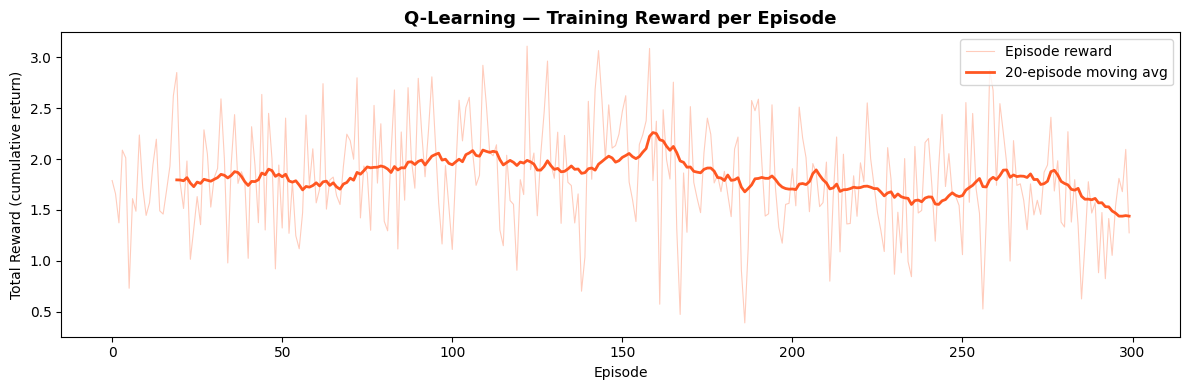

In [ ]:
# Reward curve to verify convergence
smoothed = pd.Series(episode_rewards).rolling(20).mean()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(episode_rewards, alpha=0.3, color='#FF5722', linewidth=0.8, label='Episode reward')
ax.plot(smoothed,        color='#FF5722', linewidth=2.0, label='20-episode moving avg')
ax.set_title('Q-Learning — Training Reward per Episode', fontsize=13, fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward (cumulative return)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/rl/fig_rl_training.png', bbox_inches='tight')
plt.show()

## 5.3: Evaluate on the Test Period

In [ ]:
def evaluate_agent(Q, df_eval):
    env = StockTradingEnv(df_eval.copy())
    state, done = env.reset(), False
    portfolio, actions_taken = [1.0], []
    while not done:
        action = int(np.argmax(Q[state]))
        next_state, _, done = env.step(action)
        portfolio.append(env.portfolio)
        actions_taken.append(action)
        state = next_state
    return portfolio, actions_taken

rl_portfolio, rl_actions = evaluate_agent(Q, rl_test_df)

# Buy-and-hold benchmark on the same test period
bh_returns   = (1 + rl_test_df['daily_return'].values)
bh_portfolio = np.cumprod(np.insert(bh_returns, 0, 1.0))

rl_final_return = (rl_portfolio[-1] - 1) * 100
bh_final_return = (bh_portfolio[-1] - 1) * 100

print(f'RL Agent final return    : {rl_final_return:+.2f}%')
print(f'Buy-and-Hold return      : {bh_final_return:+.2f}%')
from collections import Counter
ac = Counter(rl_actions)
print(f'Actions taken — Hold: {ac.get(0,0)} | Buy: {ac.get(1,0)} | Sell: {ac.get(2,0)}')

RL Agent final return    : +4.12%
Buy-and-Hold return      : +92.77%
Actions taken — Hold: 31 | Buy: 281 | Sell: 488


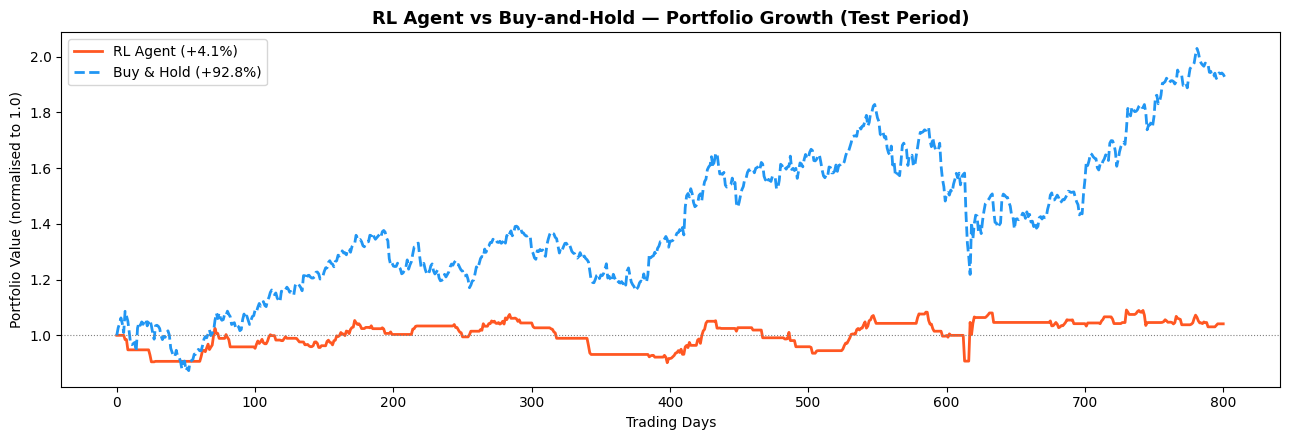

In [ ]:
# RL vs Buy-and-Hold portfolio growth
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(rl_portfolio, label=f'RL Agent ({rl_final_return:+.1f}%)',     color='#FF5722', linewidth=2)
ax.plot(bh_portfolio, label=f'Buy & Hold ({bh_final_return:+.1f}%)', color='#2196F3', linewidth=2, linestyle='--')
ax.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')
ax.set_title('RL Agent vs Buy-and-Hold — Portfolio Growth (Test Period)', fontsize=13, fontweight='bold')
ax.set_xlabel('Trading Days')
ax.set_ylabel('Portfolio Value (normalised to 1.0)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/rl/fig_rl_portfolio.png', bbox_inches='tight')
plt.show()

## 5.4: Q-Learning Hyperparameter Tuning

We sweep over learning rate α, discount factor γ, and exploration decay ε_decay to find the configuration that maximises validation portfolio return. This satisfies the hyperparameter optimisation requirement of Task 4 for the RL component.

In [ ]:
# Grid sweep — selected on the VALIDATION set, never the test set
rl_param_grid = [
    {'alpha': a, 'gamma': g, 'eps_decay': d}
    for a in [0.05, 0.1, 0.2]
    for g in [0.90, 0.95, 0.99]
    for d in [0.990, 0.995, 0.999]
]

rl_results = []
for params in rl_param_grid:
    Q_trial, _ = train_q_learning(
        rl_train_df, params['alpha'], params['gamma'],
        EPSILON, params['eps_decay'], EPS_MIN, EPISODES
    )
    val_portfolio, _ = evaluate_agent(Q_trial, rl_val_df)     # <-- VALIDATION
    val_ret = (val_portfolio[-1] - 1) * 100
    rl_results.append({**params, 'val_return_%': round(val_ret, 2)})

rl_results_df = pd.DataFrame(rl_results).sort_values('val_return_%', ascending=False).reset_index(drop=True)
print('── Q-Learning — Sweep (top 15 by VALIDATION return) ──')
print(rl_results_df.head(15).to_string(index=False))

best_rl_params = rl_results_df.iloc[0].to_dict()
print('\n── Best config (by validation) ──')
print(best_rl_params)

── Q-Learning — Sweep (top 15 by VALIDATION return) ──
 alpha  gamma  eps_decay  val_return_%
  0.05   0.99      0.995         94.21
  0.10   0.95      0.990         69.98
  0.05   0.95      0.990         68.43
  0.05   0.95      0.995         65.93
  0.10   0.95      0.995         52.92
  0.20   0.90      0.990         52.03
  0.10   0.90      0.999         40.42
  0.10   0.99      0.995         39.22
  0.05   0.90      0.990         38.09
  0.20   0.95      0.999         37.80
  0.05   0.99      0.999         32.09
  0.10   0.90      0.990         24.55
  0.05   0.99      0.990         23.26
  0.20   0.90      0.995         19.33
  0.20   0.99      0.990         13.88

── Best config (by validation) ──
{'alpha': 0.05, 'gamma': 0.99, 'eps_decay': 0.995, 'val_return_%': 94.21}


Best RL agent test return: +26.98%
Buy-and-Hold benchmark   : +92.77%


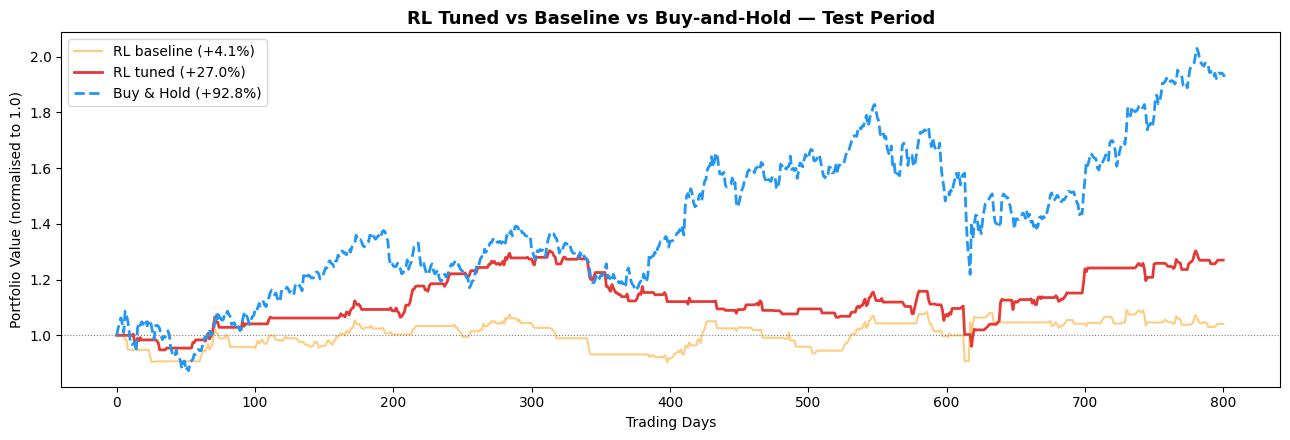

In [ ]:
# Retrain with best RL hyperparameters
Q_best, episode_rewards_best = train_q_learning(
    rl_train_df,
    best_rl_params['alpha'],
    best_rl_params['gamma'],
    EPSILON,
    best_rl_params['eps_decay'],
    EPS_MIN,
    EPISODES
)
rl_best_portfolio, rl_best_actions = evaluate_agent(Q_best, rl_test_df)
rl_best_final_return = (rl_best_portfolio[-1] - 1) * 100
print(f'Best RL agent test return: {rl_best_final_return:+.2f}%')
print(f'Buy-and-Hold benchmark   : {bh_final_return:+.2f}%')

# Plot comparison
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(rl_portfolio,      label=f'RL baseline ({rl_final_return:+.1f}%)',      color='#FFB74D', linewidth=1.5, alpha=0.7)
ax.plot(rl_best_portfolio, label=f'RL tuned ({rl_best_final_return:+.1f}%)',    color='#E53935', linewidth=2.0)
ax.plot(bh_portfolio,      label=f'Buy & Hold ({bh_final_return:+.1f}%)',       color='#2196F3', linewidth=2.0, linestyle='--')
ax.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')
ax.set_title('RL Tuned vs Baseline vs Buy-and-Hold — Test Period', fontsize=13, fontweight='bold')
ax.set_xlabel('Trading Days')
ax.set_ylabel('Portfolio Value (normalised to 1.0)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/rl/fig_rl_portfolio_tuned.png', bbox_inches='tight')
plt.show()

# Section 6: Final Results Comparison

Consolidated comparison of all models — baseline vs tuned — across Accuracy, F1, and ROC-AUC. The RL agent is shown separately because it is evaluated by portfolio return, not classification metrics.

In [64]:
# Build final summary table from accumulated results
summary_df = pd.DataFrame(all_results).T.reset_index().drop(columns=['index'])
summary_df = summary_df[['model', 'accuracy', 'f1', 'auc']]
summary_df[['accuracy','f1','auc']] = summary_df[['accuracy','f1','auc']].round(4)
summary_df = summary_df.sort_values('accuracy', ascending=False).reset_index(drop=True)
print('=== ML Model Performance Summary (sorted by Accuracy) ===')
print(summary_df.to_string(index=False))

=== ML Model Performance Summary (sorted by Accuracy) ===
                      model  accuracy        f1       auc
                        SVM  0.530587  0.564815  0.517574
              Random Forest  0.526841  0.608066  0.513678
      Random Forest (tuned)  0.516854  0.504481  0.540944
                SVM (tuned)  0.516854  0.534296  0.522186
            Voting Ensemble  0.516854  0.526316  0.514647
           LightGBM (tuned)  0.499376  0.396992  0.515977
Logistic Regression (tuned)  0.496879   0.57082  0.477827
        Logistic Regression   0.49563  0.570213  0.477909
                   LightGBM  0.466916  0.346095  0.536788


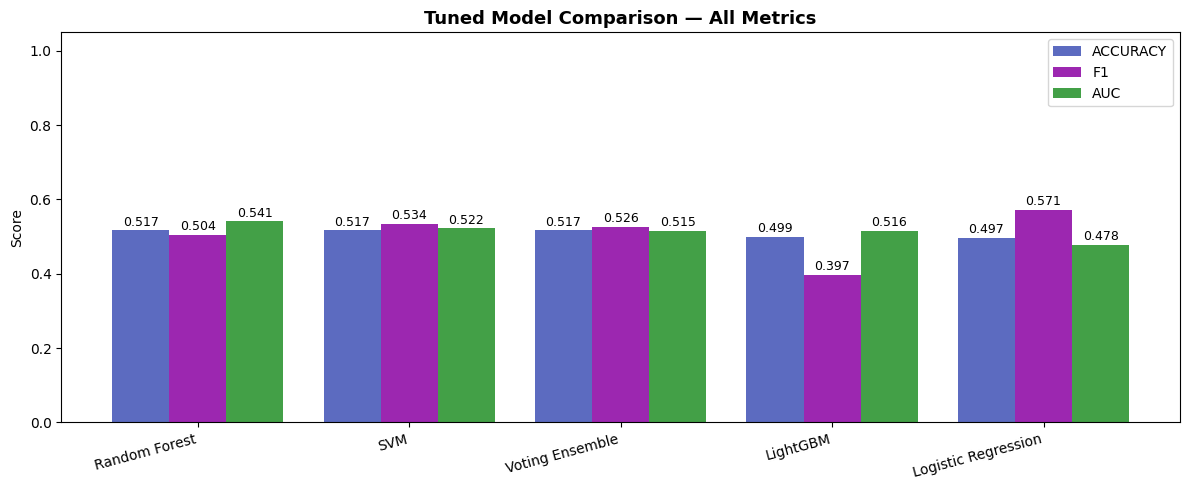

In [65]:
# Grouped bar chart of tuned models only
tuned_only = summary_df[summary_df['model'].str.contains('tuned|Ensemble', regex=True, case=False)].copy()
tuned_only['model_short'] = tuned_only['model'].str.replace(' \\(tuned\\)', '', regex=True).str.replace(' \\(Voting\\)', '', regex=True)

metrics = ['accuracy', 'f1', 'auc']
x = np.arange(len(tuned_only))
width = 0.27
colors_m = ['#5C6BC0', '#9C27B0', '#43A047']

fig, ax = plt.subplots(figsize=(12, 5))
for i, m in enumerate(metrics):
    bars = ax.bar(x + i*width, tuned_only[m].values, width, label=m.upper(), color=colors_m[i])
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x + width)
ax.set_xticklabels(tuned_only['model_short'].values, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_title('Tuned Model Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.savefig('figures/models/fig_final_comparison.png', bbox_inches='tight')
plt.show()

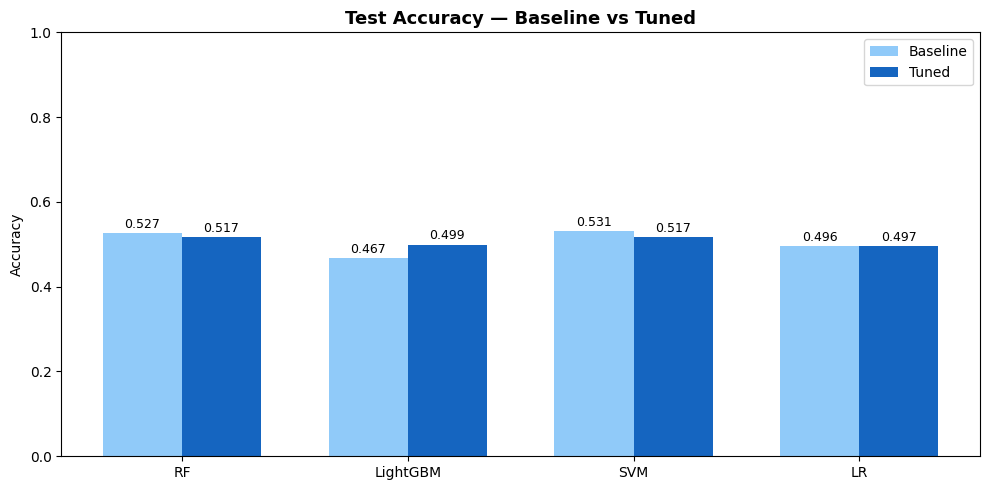

In [66]:
# Baseline vs Tuned — show improvement from hyperparameter optimisation
models_pairs = [('RF', 'RF (baseline)', 'RF (tuned)'),
                ('LightGBM', 'LGBM (baseline)', 'LGBM (tuned)'),
                ('SVM', 'SVM (baseline)', 'SVM (tuned)'),
                ('LR',  'LR (baseline)',  'LR (tuned)')]

labels = [m[0] for m in models_pairs]
baseline_acc = [all_results[m[1]]['accuracy'] for m in models_pairs]
tuned_acc    = [all_results[m[2]]['accuracy'] for m in models_pairs]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, baseline_acc, width, label='Baseline', color='#90CAF9')
b2 = ax.bar(x + width/2, tuned_acc,    width, label='Tuned',    color='#1565C0')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.set_title('Test Accuracy — Baseline vs Tuned', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.savefig('figures/models/fig_baseline_vs_tuned.png', bbox_inches='tight')
plt.show()

In [ ]:
# RL Agent summary
rl_summary = pd.DataFrame([
    {'agent': 'RL baseline', 'test_return_%': round(rl_final_return, 2),
     'alpha': ALPHA, 'gamma': GAMMA, 'eps_decay': EPS_DECAY},
    {'agent': 'RL tuned',    'test_return_%': round(rl_best_final_return, 2),
     'alpha': best_rl_params['alpha'], 'gamma': best_rl_params['gamma'], 'eps_decay': best_rl_params['eps_decay']},
    {'agent': 'Buy & Hold',  'test_return_%': round(bh_final_return, 2),
     'alpha': '—', 'gamma': '—', 'eps_decay': '—'},
])
print('=== Q-Learning Agent Summary (test period) ===')
print(rl_summary.to_string(index=False))

=== Q-Learning Agent Summary (test period) ===
      agent  test_return_% alpha gamma eps_decay
RL baseline           4.12   0.1  0.95     0.995
   RL tuned          26.98  0.05  0.99     0.995
 Buy & Hold          92.77     —     —         —


In [ ]:
# Persist all trained models so the submission ZIP contains process models
import pickle
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

pickle.dump(rf_grid.best_estimator_,   open(f'{MODEL_DIR}/rf_tuned.pkl', 'wb'))
pickle.dump(lgbm_grid.best_estimator_, open(f'{MODEL_DIR}/lgbm_tuned.pkl', 'wb'))
pickle.dump(svm_grid.best_estimator_,  open(f'{MODEL_DIR}/svm_tuned.pkl', 'wb'))
pickle.dump(lr_grid.best_estimator_,   open(f'{MODEL_DIR}/lr_tuned.pkl', 'wb'))
pickle.dump(voting_clf,                open(f'{MODEL_DIR}/voting_ensemble.pkl', 'wb'))
pickle.dump(scaler,                    open(f'{MODEL_DIR}/scaler.pkl', 'wb'))
np.save(f'{MODEL_DIR}/q_table_tuned.npy', Q_best)

summary_df.to_csv(f'{MODEL_DIR}/ml_results_summary.csv', index=False)
rl_summary.to_csv(f'{MODEL_DIR}/rl_results_summary.csv', index=False)

print(f'All models, scaler, and Q-table persisted to ./{MODEL_DIR}/')

All models, scaler, and Q-table persisted to ./models/


**Acknowledgement:** Claude AI by Anthropic was used for code generation.